# Bài 2 — Fine-tune CRNN với 4 Sub-Spectrogram

Sử dụng bộ dữ liệu **ESC-50** và xây dựng mô hình **CRNN nhiều nhánh** theo kiến trúc phân đoạn phổ tần đã học.

Mỗi file âm thanh được chia thành 4 dải tần:

- **Nhánh 1:** 0 – 3 kHz
- **Nhánh 2:** 3 – 6 kHz
- **Nhánh 3:** 6 – 10 kHz
- **Nhánh 4:** 10 – 22.05 kHz

Với mỗi dải tần, tạo một **Log-Mel Sub-Spectrogram** riêng với 60 Mel filters. Ghép thêm đặc trưng **Delta** và **Delta-Delta** để tạo tensor 3 kênh:

$$
[\text{Log-Mel},\ \Delta,\ \Delta\Delta]
$$

Mỗi Sub-Spectrogram được đưa qua một nhánh CRNN độc lập:

$$
\text{Sub-Spectrogram}
\rightarrow
\text{CNN pretrained}
\rightarrow
\text{BiGRU}
\rightarrow
\text{Fully Connected}
$$

Sau đó kết hợp xác suất dự đoán của 4 nhánh bằng **Score-Level Fusion** với trọng số:

$$
\mathbf{w} = [0.4,\ 0.2,\ 0.2,\ 0.2]
$$

## Yêu cầu

1. Tạo 4 Sub-Spectrogram tương ứng với 4 dải tần và ghép Log-Mel, Delta, Delta-Delta thành đầu vào 3 kênh.
2. Dùng **ResNet18 pretrained** làm CNN backbone cho từng nhánh; bỏ Global Average Pooling và FC để giữ feature map, đóng băng phần lớn CNN và chỉ fine-tune block cuối.
3. Tự chuyển feature map CNN từ dạng $[B, C, F', T']$ thành chuỗi $[B, T', C \times F']$ phù hợp với GRU.
4. Hoàn thiện **BiGRU + Fully Connected** cho mỗi nhánh.
5. Kết hợp kết quả của 4 nhánh bằng **weighted score-level fusion**, huấn luyện và đánh giá mô hình trên ESC-50.

> Được phép dùng `nn.GRU`, ResNet18 pretrained, `torchaudio` và các hàm training có sẵn. Trọng tâm của bài là **phân đoạn phổ tần, cách nối CNN với GRU và cách fusion kết quả của nhiều nhánh CRNN**.


## 1. Setup

In [1]:
# Nếu chạy local và thiếu thư viện, cài trước:
# pip install torch torchvision torchaudio pandas matplotlib scikit-learn

from pathlib import Path
import copy
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader

SEED = 42
SAMPLE_RATE = 44_100
CLIP_SECONDS = 5
NUM_SAMPLES = SAMPLE_RATE * CLIP_SECONDS

N_FFT = 1024
HOP_LENGTH = 441          # xấp xỉ 100 frame/giây ở 44.1 kHz
SUB_N_MELS = 60
NUM_CLASSES = 50

# 4 dải tần
SUB_BANDS = [
    (0, 3_000),
    (3_000, 6_000),
    (6_000, 10_000),
    (10_000, SAMPLE_RATE / 2),   # 22.05 kHz
]
FUSION_WEIGHTS = [0.4, 0.2, 0.2, 0.2]

# Mô hình gồm 4 nhánh CRNN nên batch size để vừa phải cho Kaggle/local GPU.
BATCH_SIZE = 8
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()


Device: cuda


## 2. Dataset và 4 Sub-Spectrogram

Mỗi đoạn âm thanh được biến đổi thành **4 Log-Mel Sub-Spectrogram**, mỗi Sub-Spectrogram chỉ quan sát một dải tần riêng.

Với từng dải, ta tạo thêm Delta và Delta-Delta rồi ghép thành 3 kênh:

$$
[1, 60, T]
\rightarrow
[3, 60, T]
$$

Cuối cùng một mẫu có dạng:

$$
[4, 3, 60, T]
$$

tương ứng với **4 nhánh CRNN**.


In [2]:
from pathlib import Path
import urllib.request
import zipfile

DATASET_URL = "https://github.com/karoldvl/ESC-50/archive/master.zip"
ZIP_PATH = Path("esc50_master.zip")
LOCAL_DATA_ROOT = Path("ESC-50-master")

# Chỉ tải nếu dataset chưa tồn tại
if (LOCAL_DATA_ROOT / "meta" / "esc50.csv").exists():
    print(f"Dataset đã tồn tại tại: {LOCAL_DATA_ROOT.resolve()}")
else:
    print("Đang tải ESC-50 (~600 MB)...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)

    print("Đang giải nén...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(".")

    ZIP_PATH.unlink()  # Xóa file zip sau khi giải nén
    print(f"Hoàn tất. Dataset ở: {LOCAL_DATA_ROOT.resolve()}")

# Kiểm tra cấu trúc dữ liệu
assert (LOCAL_DATA_ROOT / "audio").exists()
assert (LOCAL_DATA_ROOT / "meta" / "esc50.csv").exists()

Dataset đã tồn tại tại: /content/ESC-50-master


In [3]:
from IPython.display import display
# =========================================================
# DATASET PATH — KAGGLE / MÁY CÁ NHÂN
# =========================================================
#
# Kaggle:
#   1) Add một dataset chứa ESC-50.
#   2) Notebook sẽ tự tìm file meta/esc50.csv trong /kaggle/input.
#
# Local:
#   Sửa LOCAL_DATA_ROOT thành thư mục ESC-50-master của bạn.
#   Cấu trúc mong đợi:
#       ESC-50-master/
#       ├── audio/
#       └── meta/esc50.csv
# =========================================================

LOCAL_DATA_ROOT = Path(r"./ESC-50-master")  # <-- Chỉ cần sửa dòng này khi chạy local.

def resolve_esc50_root():
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        matches = list(kaggle_input.glob("**/meta/esc50.csv"))
        if matches:
            root = matches[0].parent.parent
            print("Tìm thấy ESC-50 trên Kaggle:", root)
            return root

    if (LOCAL_DATA_ROOT / "meta" / "esc50.csv").exists():
        print("Dùng ESC-50 local:", LOCAL_DATA_ROOT)
        return LOCAL_DATA_ROOT

    raise FileNotFoundError(
        "Không tìm thấy ESC-50. Hãy Add Dataset trên Kaggle hoặc sửa LOCAL_DATA_ROOT."
    )

DATA_ROOT = resolve_esc50_root()
META_CSV = DATA_ROOT / "meta" / "esc50.csv"
AUDIO_DIR = DATA_ROOT / "audio"

metadata = pd.read_csv(META_CSV)
print("Số mẫu:", len(metadata))
display(metadata.head())

Dùng ESC-50 local: ESC-50-master
Số mẫu: 2000


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [4]:
# =========================================================
# PREPROCESSING: waveform -> 4 Sub-Spectrogram
# =========================================================

# Mỗi dải tần có một MelSpectrogram transform riêng.
sub_mel_transforms = [
    torchaudio.transforms.MelSpectrogram(
        sample_rate=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=SUB_N_MELS,
        f_min=float(f_min),
        f_max=float(f_max),
        power=2.0,
    )
    for f_min, f_max in SUB_BANDS
]

db_transform = torchaudio.transforms.AmplitudeToDB(stype="power")


def build_four_sub_spectrograms(waveform):
    # =========================================================
    # TODO 1: TẠO 4 SUB-SPECTROGRAM 3 KÊNH
    #
    # Với mỗi dải tần:
    #   1) Tính Log-Mel Spectrogram.
    #   2) Tính Delta từ Log-Mel.
    #   3) Tính Delta-Delta từ Delta.
    #   4) Ghép [Log-Mel, Delta, Delta-Delta] theo chiều channel.
    #   5) Chuẩn hóa từng kênh.
    #
    # Kết quả cuối cùng cần có shape:
    #   [4, 3, SUB_N_MELS, T]
    # =========================================================

    channel_specs = []
    for mel_transform in sub_mel_transforms:
        # waveform: [1, N] -> log_mel: [SUB_N_MELS, T]
        log_mel = db_transform(mel_transform(waveform)).squeeze(0)
        delta = torchaudio.functional.compute_deltas(log_mel)
        delta_delta = torchaudio.functional.compute_deltas(delta)

        spec = torch.stack((log_mel, delta, delta_delta), dim=0)
        # Normalize each channel independently over frequency and time.
        mean = spec.mean(dim=(1, 2), keepdim=True)
        std = spec.std(dim=(1, 2), keepdim=True).clamp_min(1e-6)
        channel_specs.append((spec - mean) / std)

    return torch.stack(channel_specs, dim=0)


class ESC50Dataset(Dataset):
    def __init__(self, dataframe, audio_dir):
        self.df = dataframe.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)

    def __len__(self):
        return len(self.df)

    @staticmethod
    def _fix_length(waveform):
        if waveform.shape[-1] < NUM_SAMPLES:
            waveform = F.pad(waveform, (0, NUM_SAMPLES - waveform.shape[-1]))
        else:
            waveform = waveform[..., :NUM_SAMPLES]
        return waveform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav_path = self.audio_dir / row["filename"]

        waveform, sr = torchaudio.load(wav_path)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sr != SAMPLE_RATE:
            waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)

        waveform = self._fix_length(waveform)
        sub_specs = build_four_sub_spectrograms(waveform)

        label = int(row["target"])
        return sub_specs.float(), label


# Dùng fold chính thức của ESC-50 để ba notebook so sánh:
# Train: fold 1,2,3 | Validation: fold 4 | Test: fold 5
train_df = metadata[metadata["fold"].isin([1, 2, 3])].copy()
val_df   = metadata[metadata["fold"] == 4].copy()
test_df  = metadata[metadata["fold"] == 5].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 1200 | Val: 400 | Test: 400


/usr/local/lib/python3.13/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (60) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


Input shape: (4, 3, 60, 501)
Label: 0 - dog


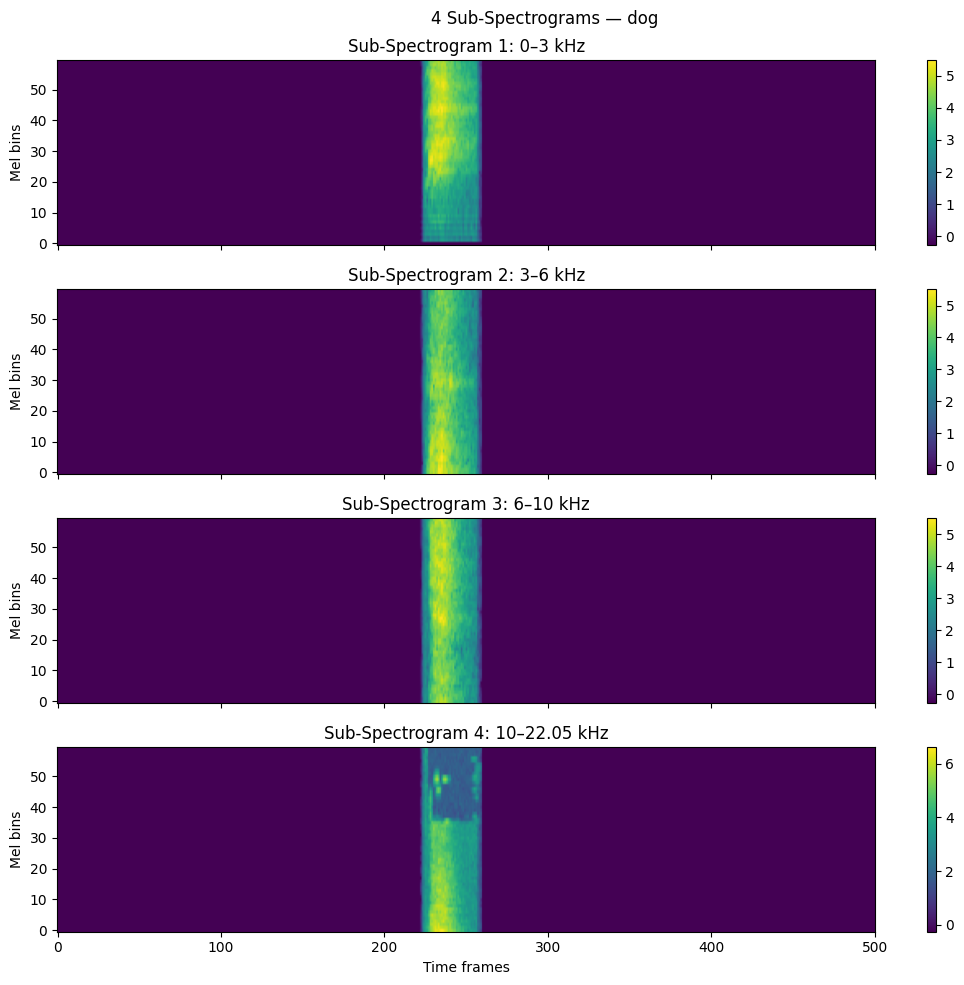

In [5]:
# =========================================================
# VISUALIZE 4 SUB-SPECTROGRAM — phần minh họa, KHÔNG phải TODO
# Chỉ hiển thị channel Log-Mel của mỗi nhánh.
# =========================================================

preview_ds = ESC50Dataset(train_df, AUDIO_DIR)
sub_specs, label = preview_ds[0]

label_name = train_df.iloc[0]["category"]
print("Input shape:", tuple(sub_specs.shape))
print("Label:", label, "-", label_name)

band_names = ["0–3 kHz", "3–6 kHz", "6–10 kHz", "10–22.05 kHz"]

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)

for i, ax in enumerate(axes):
    im = ax.imshow(
        sub_specs[i, 0].numpy(),   # channel 0 = Log-Mel
        origin="lower",
        aspect="auto",
    )
    ax.set_title(f"Sub-Spectrogram {i + 1}: {band_names[i]}")
    ax.set_ylabel("Mel bins")
    fig.colorbar(im, ax=ax)

axes[-1].set_xlabel("Time frames")
plt.suptitle(f"4 Sub-Spectrograms — {label_name}")
plt.tight_layout()
plt.show()


In [6]:
train_ds = ESC50Dataset(train_df, AUDIO_DIR)
val_ds   = ESC50Dataset(val_df, AUDIO_DIR)
test_ds  = ESC50Dataset(test_df, AUDIO_DIR)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

x, y = next(iter(train_loader))

print("Batch input :", tuple(x.shape))
print("Batch labels:", tuple(y.shape))
print("Một nhánh   :", tuple(x[:, 0].shape))

# Mong đợi:
# x        -> [B, 4, 3, 60, T]
# x[:, 0] -> [B, 3, 60, T]


Batch input : (8, 4, 3, 60, 501)
Batch labels: (8,)
Một nhánh   : (8, 3, 60, 501)


## 3. CRNN cho từng dải tần

Mỗi dải tần được xử lý bởi **một nhánh CRNN độc lập**.

Khác với Bài 1, đầu vào của mỗi nhánh đã có **3 kênh**:

$$
[\text{Log-Mel},\ \Delta,\ \Delta\Delta]
$$

nên có thể sử dụng trực tiếp lớp đầu vào 3 kênh của ResNet18 pretrained.

Điểm quan trọng là phải **bỏ Global Average Pooling và FC của ResNet**, vì cần giữ feature map theo trục thời gian trước khi đưa sang BiGRU.


In [7]:
from collections import OrderedDict
from torchvision.models import resnet18, ResNet18_Weights

def load_pretrained_resnet18():
    return resnet18(weights=ResNet18_Weights.DEFAULT)


## 4. Xây dựng một nhánh CRNN

Output CNN của mỗi nhánh có dạng:

$$
[B, C, F', T']
$$

BiGRU cần một chuỗi vector:

$$
[B, T', D], \quad D = C \times F'
$$

Do đó ta giữ $T'$ làm **sequence length**, còn $C$ và $F'$ được ghép thành **feature dimension**.

Với đầu vào có 60 Mel bins, ResNet18 giảm chiều tần số xuống còn 2 bins ở cuối `layer4`, do đó:

$$
D = 512 \times 2 = 1024
$$


In [8]:
class CRNNBranch(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, hidden_size=256, num_gru_layers=2):
        super().__init__()

        backbone = load_pretrained_resnet18()

        # =========================================================
        # TODO 2: TẠO CNN FEATURE EXTRACTOR VÀ THIẾT LẬP FINE-TUNING
        #
        # - Giữ: conv1, bn1, relu, maxpool, layer1..layer4.
        # - Bỏ: avgpool và fc.
        # - Freeze phần lớn CNN.
        # - Chỉ unfreeze layer4.
        # =========================================================
        self.cnn = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4,
        )
        for parameter in self.cnn.parameters():
            parameter.requires_grad = False
        for parameter in backbone.layer4.parameters():
            parameter.requires_grad = True

        # Với 60 Mel bins:
        # 60 -> 30 -> 15 -> 15 -> 8 -> 4 -> 2 qua ResNet18.
        # Cuối layer4 có 512 channels nên GRU input = 512 * 2.
        gru_input_size = 512 * 2

        # =========================================================
        # TODO 4 (phần A): KHỞI TẠO BiGRU + CLASSIFIER
        #
        # - BiGRU dùng batch_first=True, bidirectional=True.
        # - FC nhận concatenation hidden state của hai hướng.
        # =========================================================
        self.gru = nn.GRU(
            input_size=gru_input_size, hidden_size=hidden_size,
            num_layers=num_gru_layers, batch_first=True, bidirectional=True,
        )
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def feature_map_to_sequence(self, feature_map):
        # feature_map: [B, C, F', T']

        # =========================================================
        # TODO 3: CNN FEATURE MAP -> TEMPORAL SEQUENCE
        #
        # Chuyển:
        #   [B, C, F', T'] -> [B, T', C*F']
        # =========================================================

        batch_size, channels, freq_bins, time_steps = feature_map.shape
        return feature_map.permute(0, 3, 1, 2).reshape(
            batch_size, time_steps, channels * freq_bins
        )

    def forward(self, x):
        feature_map = self.cnn(x)
        sequence = self.feature_map_to_sequence(feature_map)

        # =========================================================
        # TODO 4 (phần B): HOÀN THIỆN BiGRU + FC
        #
        # - Đưa sequence qua BiGRU.
        # - Lấy hidden state cuối của forward và backward ở layer cuối.
        # - Concatenate hai vector và đưa qua classifier.
        # =========================================================
        _, hidden = self.gru(sequence)
        # hidden[-2] and hidden[-1] are forward/backward states of last layer.
        final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.classifier(final_hidden)


class MultiBandCRNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        # =========================================================
        # TODO 5: TẠO 4 NHÁNH CRNN VÀ SCORE-LEVEL FUSION
        #
        # - Tạo 4 CRNNBranch độc lập.
        # - Mỗi nhánh nhận x[:, i] có shape [B, 3, 60, T].
        # - Chuyển logits từng nhánh thành probability bằng softmax.
        # - Fusion với trọng số [0.4, 0.2, 0.2, 0.2].
        # - Trả về log-probability để dùng cùng nn.NLLLoss().
        # =========================================================
        self.branches = nn.ModuleList([
            CRNNBranch(num_classes=num_classes) for _ in range(4)
        ])
        self.register_buffer(
            "fusion_weights", torch.tensor(FUSION_WEIGHTS, dtype=torch.float32)
        )

    def forward(self, x):
        # x: [B, 4, 3, 60, T]

        branch_probabilities = torch.stack([
            torch.softmax(branch(x[:, i]), dim=1)
            for i, branch in enumerate(self.branches)
        ], dim=1)
        fused_probabilities = (
            branch_probabilities * self.fusion_weights.view(1, -1, 1)
        ).sum(dim=1)
        return torch.log(fused_probabilities.clamp_min(1e-8))


## 5. Quick shape test

Cell này chỉ dùng để kiểm tra luồng dữ liệu qua **một nhánh** và qua **toàn bộ 4 nhánh**.


In [9]:
set_seed()
model = MultiBandCRNN().to(DEVICE)

x, _ = next(iter(train_loader))
x_small = x[:2].to(DEVICE)

with torch.no_grad():
    branch_0 = model.branches[0]

    feature_map = branch_0.cnn(x_small[:, 0])
    sequence = branch_0.feature_map_to_sequence(feature_map)
    branch_logits = branch_0(x_small[:, 0])
    log_probs = model(x_small)

print("Input 4 branches  :", tuple(x_small.shape))
print("Một branch input  :", tuple(x_small[:, 0].shape))
print("CNN feature map   :", tuple(feature_map.shape))
print("GRU sequence      :", tuple(sequence.shape))
print("Branch logits     :", tuple(branch_logits.shape))
print("Fused output      :", tuple(log_probs.shape))

assert log_probs.shape == (2, NUM_CLASSES)


Input 4 branches  : (2, 4, 3, 60, 501)
Một branch input  : (2, 3, 60, 501)
CNN feature map   : (2, 512, 2, 16)
GRU sequence      : (2, 16, 1024)
Branch logits     : (2, 50)
Fused output      : (2, 50)


## 6. Huấn luyện và đánh giá

Mô hình fusion trả về **log-probability**, vì vậy sử dụng `nn.NLLLoss()` thay cho `nn.CrossEntropyLoss()`.


In [10]:
# =========================================================
# TRAIN / EVALUATE HELPERS
# =========================================================

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_targets = []
    all_preds = []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        log_probs = model(x)
        loss = criterion(log_probs, y)

        total_loss += loss.item() * x.size(0)
        preds = log_probs.argmax(dim=1)

        total_correct += (preds == y).sum().item()
        total_samples += x.size(0)
        all_targets.extend(y.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "targets": all_targets,
        "preds": all_preds,
    }


def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1.0
    best_state = None
    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_samples = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            log_probs = model(x)
            loss = criterion(log_probs, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_correct += (log_probs.argmax(dim=1) == y).sum().item()
            running_samples += x.size(0)

        train_loss = running_loss / running_samples
        train_acc = running_correct / running_samples

        val_result = evaluate(model, val_loader, criterion)
        val_loss = val_result["loss"]
        val_acc = val_result["accuracy"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss={train_loss:.4f}, acc={train_acc:.4f} | "
            f"val loss={val_loss:.4f}, acc={val_acc:.4f}"
        )

    training_seconds = time.perf_counter() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_acc, training_seconds


def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.show()


Total params: 57,416,136
Trainable params: 46,285,000
Epoch 01/10 | train loss=3.5556, acc=0.1392 | val loss=3.0693, acc=0.2300
Epoch 02/10 | train loss=2.5712, acc=0.4458 | val loss=2.4197, acc=0.4150
Epoch 03/10 | train loss=1.8409, acc=0.7117 | val loss=2.1925, acc=0.4375
Epoch 04/10 | train loss=1.3643, acc=0.8750 | val loss=1.9333, acc=0.5100
Epoch 05/10 | train loss=1.0567, acc=0.9383 | val loss=1.8105, acc=0.5550
Epoch 06/10 | train loss=0.8747, acc=0.9608 | val loss=1.7488, acc=0.5700
Epoch 07/10 | train loss=0.7162, acc=0.9892 | val loss=1.7077, acc=0.5900
Epoch 08/10 | train loss=0.6031, acc=0.9975 | val loss=1.6514, acc=0.6150
Epoch 09/10 | train loss=0.5099, acc=1.0000 | val loss=1.7090, acc=0.5675
Epoch 10/10 | train loss=0.4312, acc=1.0000 | val loss=1.6255, acc=0.5875


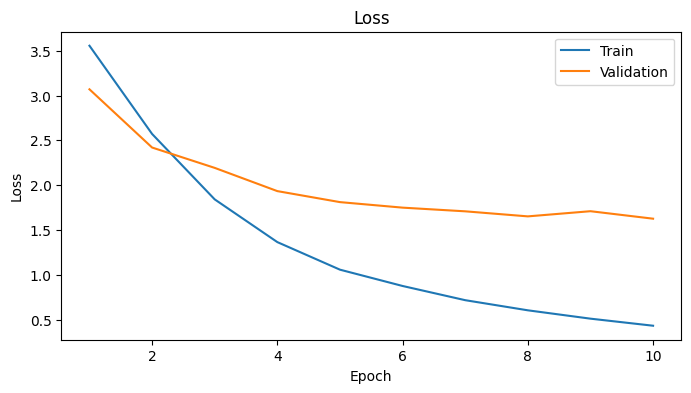

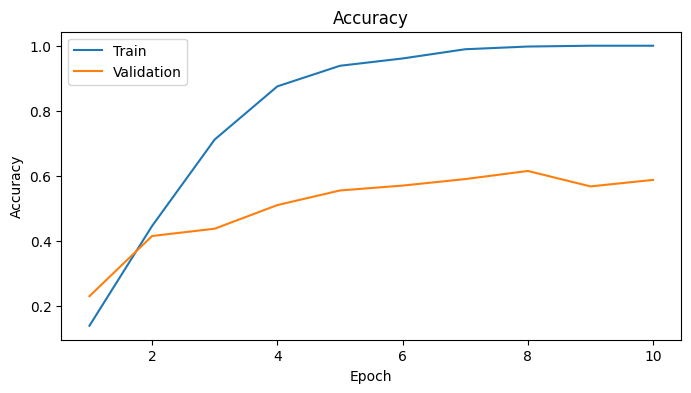

Best validation accuracy: 0.6150
Test accuracy: 0.5700
Training time (s): 575.86


In [11]:
EPOCHS = 10
LEARNING_RATE = 1e-4

set_seed()

# MultiBandCRNN trả log-probability sau weighted fusion.
criterion = nn.NLLLoss()

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

total_params, trainable_params = count_parameters(model)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

history, best_val_acc, training_seconds = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    EPOCHS,
)

torch.save(model.state_dict(), "multiband_crnn_esc50_best.pt")

test_result = evaluate(model, test_loader, criterion)
plot_history(history)

print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Test accuracy: {test_result['accuracy']:.4f}")
print(f"Training time (s): {training_seconds:.2f}")


## 7. Kết quả và nhận xét

Ghi lại:

- Best validation accuracy:
- Test accuracy:
- Trainable parameters:
- Training time:

**Nhận xét kết quả:**

Sau khi chạy cell huấn luyện, điền các chỉ số được in ra ở trên. Nếu validation accuracy cao hơn test accuracy không đáng kể thì mô hình có khả năng tổng quát hóa tương đối tốt. Ngược lại, nếu chênh lệch lớn hoặc validation loss tăng trong khi train loss tiếp tục giảm, đó là dấu hiệu overfitting; có thể tăng augmentation, regularization hoặc dừng sớm. Số trainable parameters nhỏ hơn tổng số tham số vì chỉ `layer4` của mỗi ResNet18 và phần BiGRU/classifier được fine-tune, giúp giảm chi phí huấn luyện và hạn chế overfitting trên ESC-50.

**Trả lời câu hỏi nhận xét:**

1. Mỗi dải tần chứa những đặc trưng âm học khác nhau: dải thấp thường mang năng lượng nền, nhịp và tiếng động cơ; dải trung/cao chứa nhiều chi tiết như tiếng va chạm, tiếng còi hoặc tiếng chim. Tách thành bốn nhánh giúp mỗi CRNN chuyên biệt hóa việc học đặc trưng theo dải, giảm việc các thành phần năng lượng mạnh che lấp đặc trưng yếu ở dải khác. Fusion sau đó kết hợp các bằng chứng này để phân loại ổn định hơn so với chỉ dùng một biểu diễn toàn dải.

2. CNN tạo feature map theo cả tần số và thời gian. Khi đưa vào GRU, trục thời gian phải là sequence axis để mỗi bước của GRU tương ứng với một thời điểm âm thanh và GRU có thể học sự phụ thuộc trước–sau, chẳng hạn diễn tiến của tiếng còi hoặc nhịp lặp của tiếng động cơ. Chiều channel và tần số được gộp thành feature vector tại từng thời điểm vì chúng mô tả nội dung phổ ở thời điểm đó, không phải thứ tự tuần tự.

3. Trọng số $[0.4,\ 0.2,\ 0.2,\ 0.2]$ ưu tiên xác suất từ nhánh 0–3 kHz: nhánh này đóng góp 40% vào dự đoán cuối, gấp đôi từng nhánh còn lại. Đây là giả định rằng nhiều lớp âm thanh môi trường trên ESC-50 có thông tin phân biệt mạnh ở tần số thấp. Tuy nhiên, đây là trọng số thiết kế sẵn chứ không chứng minh dải thấp luôn quan trọng nhất; nên thử ablation hoặc học trọng số fusion từ validation set để kiểm chứng và tối ưu.
